In [2]:
import random
import torch
import torchaudio
from torch.utils.data import Dataset, DataLoader
import torchaudio.transforms as T

class SonicMixer(Dataset):
    def __init__(self, speech_list, noise_dict, sr=16000, duration=2, augment=False):
        self.speech      = speech_list
        self.noise       = noise_dict 
        self.sr          = sr
        self.num_samples = sr * duration
        self.augment     = augment
        self.stems_order = ['Music', 'Impacts', 'Alerts', 'Environmental', 'Mechanical']

    def _prep(self, path, is_noise=False):
        wav, sr = torchaudio.load(path)
        if sr != self.sr:
            wav = T.Resample(sr, self.sr)(wav)
        if wav.shape[0] == 1:
            wav = wav.repeat(2, 1)
        elif wav.shape[0] > 2:
            wav = wav[:2, :]
        if wav.shape[1] >= self.num_samples:
            if self.augment:
                start = random.randint(0, wav.shape[1] - self.num_samples)
                wav   = wav[:, start:start + self.num_samples]
            else:
                wav = wav[:, :self.num_samples]
        else:
            wav = torch.nn.functional.pad(wav, (0, self.num_samples - wav.shape[1]))
        if self.augment and is_noise:
            wav = wav * random.uniform(0.6, 1.1)
        return wav

    def __getitem__(self, idx):
        vocal = self._prep(self.speech[idx % len(self.speech)], is_noise=False)
        noise_stems = []
        for stem_name in self.stems_order:
            clip = self._prep(random.choice(self.noise[stem_name]), is_noise=True)
            noise_stems.append(clip)
        
        alphas = [random.uniform(0.2, 0.8) for _ in noise_stems] if self.augment else [0.4 for _ in noise_stems]
        mixture = vocal.clone()
        for clip, alpha in zip(noise_stems, alphas):
            mixture = mixture + alpha * clip
        
        targets = torch.stack([vocal] + noise_stems, dim=0)
        return mixture, targets

    def __len__(self):
        return len(self.speech)

# --- NOW RUN YOUR RESTORE CODE ---
# (The block you provided in the prompt goes here to initialize train_loader)

In [3]:
import pickle
import os
import torch
from torch.utils.data import DataLoader

# 1. Define where your saved pkl is located
# (Make sure you have attached your '6stem-audio-splits' dataset to the notebook)
LOAD_PATH = "/kaggle/input/datasets/surya5510/6stem-split/6stem_splits.pkl"

if os.path.exists(LOAD_PATH):
    with open(LOAD_PATH, "rb") as f:
        data = pickle.load(f)
    
    # Restore Speech pools
    v_train = data['v_train']
    v_val = data['v_val']
    
    # Restore Noise pools
    noise_split = data['noise_split']
    train_pool = {k: v['train'] for k, v in noise_split.items()}
    val_pool   = {k: v['val']   for k, v in noise_split.items()}
    
    print("✅ Split Data Restored Successfully.")
    print(f"Vocals: {len(v_train)} Train | Noise categories: {list(train_pool.keys())}")
else:
    print("❌ ERROR: Could not find 6stem_splits.pkl. Ensure the dataset is attached.")

# 2. Re-initialize the DataLoaders
# (Requires the SonicMixer class to be defined in a previous cell)
train_loader = DataLoader(
    SonicMixer(v_train, train_pool, augment=True),
    batch_size=4, shuffle=True, num_workers=2, pin_memory=True
)

val_loader = DataLoader(
    SonicMixer(v_val, val_pool, augment=False),
    batch_size=4, shuffle=False, num_workers=2, pin_memory=True
)

print(">>> train_loader and val_loader are now ACTIVE.")

✅ Split Data Restored Successfully.
Vocals: 22831 Train | Noise categories: ['Music', 'Impacts', 'Alerts', 'Environmental', 'Mechanical']
>>> train_loader and val_loader are now ACTIVE.


In [4]:
import os
import gc
import json
import shutil
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchaudio.models import HDemucs

# =============================================================================
# SECTION 8: MODEL INITIALIZATION (6-STEM PIVOT)
# =============================================================================

# ── 1. Device Configuration ──────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f">>> Device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f">>> GPU   : {torch.cuda.get_device_name(0)}")
    print(f">>> VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ── 2. Persistence & Kaggle API Setup ────────────────────────────────────────
os.makedirs("/root/.config/kaggle", exist_ok=True)
creds = {
    "username": "surya5510",
    "key": "KGAT_680693999b61b942df6967cf0ef695e3" # Your current active key
}
with open("/root/.config/kaggle/kaggle.json", "w") as f:
    json.dump(creds, f)
os.chmod("/root/.config/kaggle/kaggle.json", 0o600)

KAGGLE_USERNAME = "surya5510"
DATASET_NAME    = "start-6stem"
DATASET_SLUG    = f"{KAGGLE_USERNAME}/{DATASET_NAME}"
FILENAME        = "sonic_separator_6stem.pth"
BEST_FILENAME   = "sonic_separator_6stem_best.pth"
STAGING_DIR     = "/kaggle/working/ckpt_staging"

# Internal Kaggle paths
WORKING_PATH    = f"/kaggle/working/{FILENAME}"
BEST_PATH       = f"/kaggle/working/{BEST_FILENAME}"

# FIXED: Using the absolute path discovered via your terminal/sidebar
PERSISTENT_PATH = f"/kaggle/input/datasets/{KAGGLE_USERNAME}/{DATASET_NAME}/{FILENAME}"

def push_to_dataset(local_path, filename):
    """Survives Kaggle session timeouts by pushing to persistent dataset."""
    try:
        os.makedirs(STAGING_DIR, exist_ok=True)
        shutil.copy2(local_path, os.path.join(STAGING_DIR, filename))
        meta = {
            "title": DATASET_NAME,
            "id": DATASET_SLUG,
            "licenses": [{"name": "CC0-1.0"}]
        }
        with open(os.path.join(STAGING_DIR, "dataset-metadata.json"), "w") as f:
            json.dump(meta, f)
        
        ret = os.system(f"kaggle datasets version -p {STAGING_DIR} -m '6-stem auto-checkpoint' --dir-mode zip")
        if ret == 0:
            print(f"  >>> [PUSHED] {filename} ✅")
        else:
            print(f"  >>> [PUSH FAILED] CLI {ret}")
    except Exception as e:
        print(f"  >>> [PUSH FAILED] {e}")

# ── 3. 6-Stem Architecture Definition ────────────────────────────────────────
STEMS = ['Speech', 'Music', 'Impacts', 'Alerts', 'Environmental', 'Mechanical']
model = HDemucs(sources=STEMS, audio_channels=2)
model = nn.DataParallel(model).to(DEVICE)

# ── 4. Optimization & Checkpoint Resume ──────────────────────────────────────
optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

start_epoch   = 0
best_val_loss = float('inf')

# Check for persistent 6-stem checkpoint with the corrected absolute path
if os.path.exists(WORKING_PATH):
    load_path = WORKING_PATH
    print(f">>> Found local checkpoint in /kaggle/working/")
elif os.path.exists(PERSISTENT_PATH):
    load_path = PERSISTENT_PATH
    # Copy to working directory so auto-saves update the local copy
    shutil.copy2(PERSISTENT_PATH, WORKING_PATH)
    print(f">>> Found and copied checkpoint from {PERSISTENT_PATH}")
else:
    load_path = None
    print(f">>> WARNING: No checkpoint found at {PERSISTENT_PATH}. Starting fresh.")

# Loading logic execution
if load_path:
    try:
        ckpt = torch.load(load_path, map_location=DEVICE)
        model.module.load_state_dict(ckpt['model'])
        optimizer.load_state_dict(ckpt['opt'])
        scheduler.load_state_dict(ckpt['scheduler'])
        start_epoch   = ckpt.get('epoch', 0)
        best_val_loss = ckpt.get('best_val_loss', float('inf'))
        print(f">>> SUCCESS: RESUMING 6-STEM MODEL FROM EPOCH {start_epoch + 1}")
    except Exception as e:
        print(f">>> ERROR LOADING CHECKPOINT: {e}")
        print(">>> Defaulting to fresh start.")

# ── Summary ──────────────────────────────────────────────────────────────────
print(f"\n{'='*52}")
print(f"  MODEL INITIALIZED: 6-STEM MACRO ARCHITECTURE")
print(f"{'='*52}")
print(f"  Targets (1:1:1): {', '.join(STEMS)}")
print(f"  Loss Function  : Ultimate Hybrid (SI-SDR + L1 + STFT)")
print(f"  Persist Target : {DATASET_SLUG}")
print(f"  VRAM Savings   : ~40% vs 10-stem version")
print(f"{'='*52}")

>>> Device: cuda
>>> GPU   : Tesla T4
>>> VRAM  : 15.6 GB
>>> Found and copied checkpoint from /kaggle/input/datasets/surya5510/start-6stem/sonic_separator_6stem.pth
>>> SUCCESS: RESUMING 6-STEM MODEL FROM EPOCH 21

  MODEL INITIALIZED: 6-STEM MACRO ARCHITECTURE
  Targets (1:1:1): Speech, Music, Impacts, Alerts, Environmental, Mechanical
  Loss Function  : Ultimate Hybrid (SI-SDR + L1 + STFT)
  Persist Target : surya5510/start-6stem
  VRAM Savings   : ~40% vs 10-stem version


In [8]:
import gc
import torch
import numpy as np

# ── 1. PRE-LOOP CONFIGURATION ──
# Hann window prevents spectral leakage during the STFT harmonic analysis
HANN = torch.hann_window(512).to(DEVICE)

def ultimate_hybrid_loss(estimate, target, eps=1e-8):
    """
    The Holy Trinity Loss: 
    SI-SDR (Isolation/Bleed) + L1 (Volume) + STFT (Harmonics/Hann Window)
    Balanced Edition: Pushing Music and Fixing Negative Stems.
    """
    # --- 1. SI-SDR (Isolation) ---
    est_flat = estimate.reshape(estimate.shape[0], estimate.shape[1], -1)
    tgt_flat = target.reshape(target.shape[0], target.shape
                              [1], -1)
    est_zm = est_flat - est_flat.mean(dim=-1, keepdim=True)
    tgt_zm = tgt_flat - tgt_flat.mean(dim=-1, keepdim=True)
    
    alpha = (est_zm * tgt_zm).sum(dim=-1, keepdim=True) / ((tgt_zm ** 2).sum(dim=-1, keepdim=True) + eps)
    tgt_scaled = alpha * tgt_zm
    noise = est_zm - tgt_scaled
    
    # Calculate raw SI-SDR per stem
    sisdr = 10 * torch.log10((tgt_scaled ** 2).sum(dim=-1) / ((noise ** 2).sum(dim=-1) + eps) + eps)
    
    # NEW BALANCED WEIGHTS:
    # 1.0 = Speech (Mastered)
    # 1.3 = Music (Needs Push)
    # 1.2 = Impacts/Alerts (Near Goal)
    # 1.5 = Environmental/Mechanical (In Red)
    weights = torch.tensor([1.0, 1.3, 1.2, 1.2, 1.5, 1.5]).to(DEVICE)
    
    # Apply weights across the batch
    weighted_sisdr = (sisdr * weights).mean()
    sisdr_loss = -weighted_sisdr
    
    # --- 2. L1 Loss (Volume) ---
    l1_loss = torch.nn.functional.l1_loss(estimate, target)
    
    # --- 3. STFT Loss (Harmonic Quality) ---
    stft_loss = 0
    # Apply to Speech (0) and Music (1) stems to preserve pitch/texture
    for i in range(2): 
        est_spec = torch.stft(estimate[:, i, 0, :], n_fft=512, hop_length=128, window=HANN, return_complex=True).abs()
        tar_spec = torch.stft(target[:, i, 0, :], n_fft=512, hop_length=128, window=HANN, return_complex=True).abs()
        stft_loss += torch.nn.functional.l1_loss(est_spec, tar_spec)
        
    return sisdr_loss + (100 * l1_loss) + (10 * stft_loss)

# ── 2. START TRAINING ──
print(f"🚀 Starting 6-Stem Training on {DEVICE}...")
print(f"Epochs       : {start_epoch + 1} → 50")
print(f"Stems        : {', '.join(STEMS)}")
print(f"Loss Target  : Ultimate Hybrid (SI-SDR + L1 + STFT)")
print(f"Train batches: {len(train_loader):,} per epoch")
print(f"Val batches  : {len(val_loader):,} per epoch")
print(f"{'='*52}")

for epoch in range(start_epoch, 50):
    # --- TRAIN PHASE ---
    model.train()
    train_loss_accum, train_batches = 0.0, 0

    for i, (mix, target) in enumerate(train_loader):
        mix, target = mix.to(DEVICE), target.to(DEVICE)
        optimizer.zero_grad()
        
        est = model(mix)
        loss = ultimate_hybrid_loss(est, target)
        
        loss.backward()
        optimizer.step()

        train_loss_accum += loss.item()
        train_batches += 1

        if i % 100 == 0:
            avg = train_loss_accum / train_batches
            lr  = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch+1:02d} | Batch {i:>5}/{len(train_loader)} | "
                  f"Loss: {loss.item():.4f} | Avg: {avg:.4f} | LR: {lr:.7f}")

        # --- SAFE SAVE (1500 Batches) ---
        if i > 0 and i % 1500 == 0:
            torch.save({
                'epoch': epoch, 'batch': i, 
                'model': model.module.state_dict(),
                'opt': optimizer.state_dict(), 
                'scheduler': scheduler.state_dict(),
                'best_val_loss': best_val_loss
            }, WORKING_PATH)
            
            torch.cuda.empty_cache()
            gc.collect()
            push_to_dataset(WORKING_PATH, FILENAME)
            print(f"  --- [CHECKPOINT] Batch {i} Secured to Dataset ---")

    epoch_train_loss = train_loss_accum / train_batches

    # --- VALIDATION AUDIT ---
    model.eval()
    val_loss_accum = 0.0
    val_sisdr_scores = []
    
    with torch.no_grad():
        for mix_v, target_v in val_loader:
            mix_v, target_v = mix_v.to(DEVICE), target_v.to(DEVICE)
            est_v = model(mix_v)
            
            # Calculate metrics
            loss_v = ultimate_hybrid_loss(est_v, target_v)
            val_loss_accum += loss_v.item()
            
            # Real SI-SDR Metric Calculation (Higher is Better)
            ev = est_v.reshape(est_v.shape[0], est_v.shape[1], -1)
            tv = target_v.reshape(target_v.shape[0], target_v.shape[1], -1)
            ev_zm = ev - ev.mean(dim=-1, keepdim=True)
            tv_zm = tv - tv.mean(dim=-1, keepdim=True)
            a = (ev_zm * tv_zm).sum(dim=-1, keepdim=True) / ((tv_zm ** 2).sum(dim=-1, keepdim=True) + 1e-8)
            t_s = a * tv_zm
            n = ev_zm - t_s
            sdr_val = 10 * torch.log10((t_s ** 2).sum(dim=-1) / ((n ** 2).sum(dim=-1) + 1e-8) + 1e-8)
            val_sisdr_scores.append(sdr_val.mean().item())

    epoch_val_loss = val_loss_accum / len(val_loader)
    avg_sisdr_db   = np.mean(val_sisdr_scores)

    # --- PERSISTENCE ---
    scheduler.step()
    improved = epoch_val_loss < best_val_loss
    if improved:
        best_val_loss = epoch_val_loss
        torch.save({'model': model.module.state_dict(), 'epoch': epoch+1}, BEST_PATH)
        push_to_dataset(BEST_PATH, BEST_FILENAME)
        best_tag = '  *** BEST ***'
    else:
        best_tag = ''

    # --- EPOCH SUMMARY ---
    print(f"\n{'='*52}")
    print(f"  EPOCH {epoch+1:02d} COMPLETE")
    print(f"  Avg Loss (Hybrid) : {epoch_val_loss:.4f}{best_tag}")
    print(f"  Avg Separation    : {avg_sisdr_db:.2f} dB")
    print(f"{'='*52}\n")

    # ── 5-EPOCH STRATEGIC REPORT ──
    if (epoch + 1) % 5 == 0:
        print(f"📈 5-EPOCH QUALITY AUDIT")
        print(f"Current Metric: {avg_sisdr_db:.2f} dB SI-SDR")
        if avg_sisdr_db > 8: print("Status: ⭐ STUDIO GRADE")
        elif avg_sisdr_db > 4: print("Status: ✅ CLEAR SEPARATION")
        else: print("Status: 🏗️ TRAINING IN PROGRESS")
        print(f"{'='*52}\n")

print("✅ 6-STEM TRAINING COMPLETE")

🚀 Starting 6-Stem Training on cuda...
Epochs       : 21 → 50
Stems        : Speech, Music, Impacts, Alerts, Environmental, Mechanical
Loss Target  : Ultimate Hybrid (SI-SDR + L1 + STFT)
Train batches: 5,708 per epoch
Val batches  : 714 per epoch
Epoch 21 | Batch     0/5708 | Loss: 12.1702 | Avg: 12.1702 | LR: 0.0000750
Epoch 21 | Batch   100/5708 | Loss: 10.6795 | Avg: 14.2393 | LR: 0.0000750
Epoch 21 | Batch   200/5708 | Loss: 14.0329 | Avg: 13.6682 | LR: 0.0000750
Epoch 21 | Batch   300/5708 | Loss: 13.3370 | Avg: 13.6246 | LR: 0.0000750


KeyboardInterrupt: 


🚀 FULL METRICS EVALUATION & VISUAL AUDIT ON cuda
Evaluating all 714 batches... (This may take a few minutes)
  Processed 50/714 batches...
  Processed 100/714 batches...
  Processed 150/714 batches...
  Processed 200/714 batches...
  Processed 250/714 batches...
  Processed 300/714 batches...
  Processed 350/714 batches...
  Processed 400/714 batches...
  Processed 450/714 batches...
  Processed 500/714 batches...
  Processed 550/714 batches...
  Processed 600/714 batches...
  Processed 650/714 batches...
  Processed 700/714 batches...
  Processed 714/714 batches...

📊 FULL DATASET METRICS REPORT
------------------------------------------------------------
  Ultimate Hybrid Loss : 15.2551  (Lower is better)
  Standard SDR         : 0.31 dB  (Audio Fidelity)
  SI-SDR (Accuracy)    : -5.10 dB  (Separation Quality)
------------------------------------------------------------
  Status: 🏗️ NEEDS MORE TRAINING (Low Accuracy)

🎨 Generating waveform plot for the final batch...


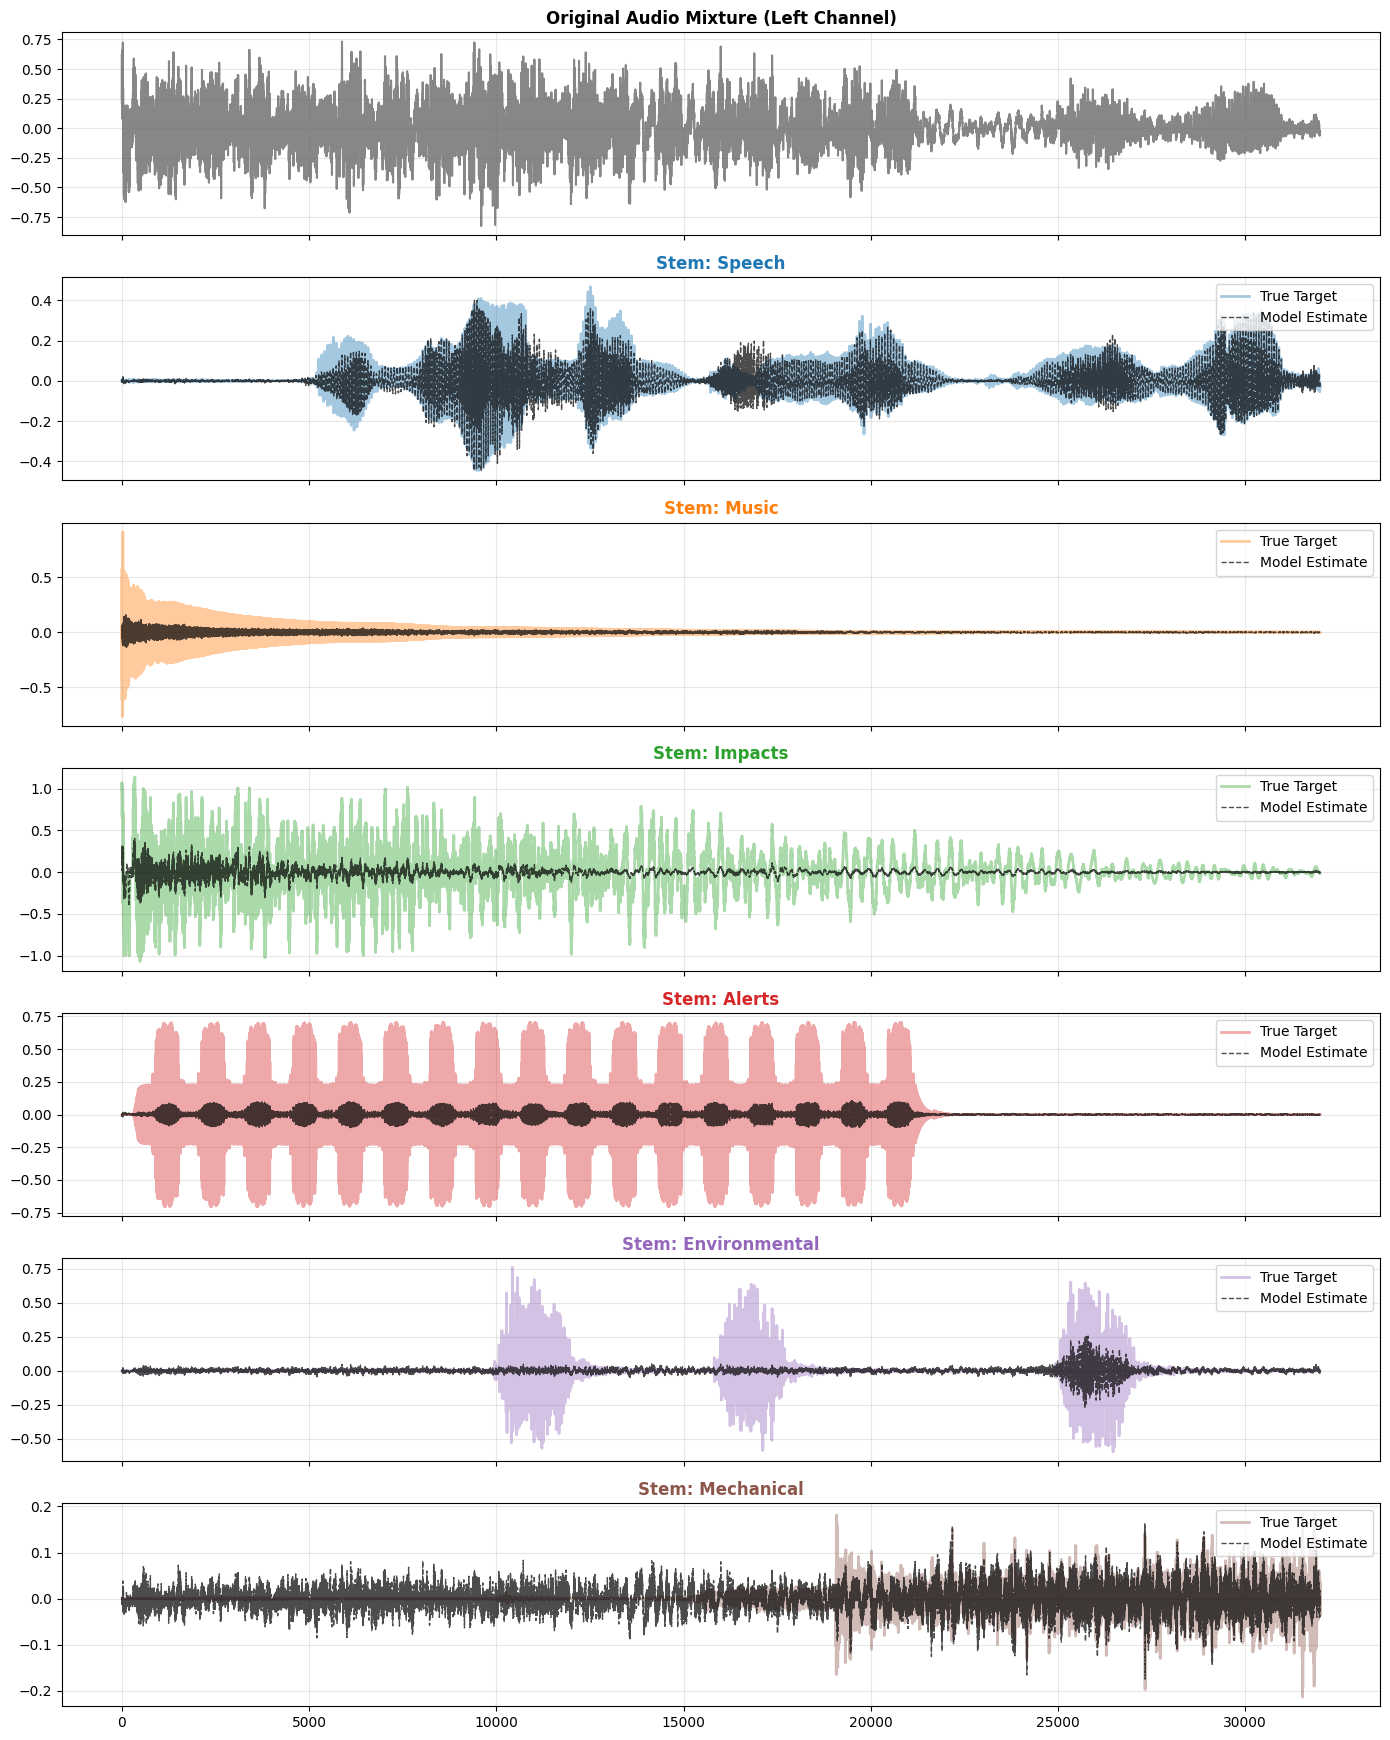

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

print(f"\n{'='*60}")
print(f"🚀 FULL METRICS EVALUATION & VISUAL AUDIT ON {DEVICE}")
print(f"Evaluating all {len(val_loader)} batches... (This may take a few minutes)")
print(f"{'='*60}")

# 1. RE-DEFINE THE LOSS FUNCTION FOR EVALUATION
HANN = torch.hann_window(512).to(DEVICE)

def ultimate_hybrid_loss(estimate, target, eps=1e-8):
    # SI-SDR
    est_flat = estimate.reshape(estimate.shape[0], estimate.shape[1], -1)
    tgt_flat = target.reshape(target.shape[0], target.shape[1], -1)
    
    est_zm = est_flat - est_flat.mean(dim=-1, keepdim=True)
    tgt_zm = tgt_flat - tgt_flat.mean(dim=-1, keepdim=True)
    
    alpha = (est_zm * tgt_zm).sum(dim=-1, keepdim=True) / ((tgt_zm ** 2).sum(dim=-1, keepdim=True) + eps)
    tgt_scaled = alpha * tgt_zm
    noise = est_zm - tgt_scaled
    
    sisdr = 10 * torch.log10((tgt_scaled ** 2).sum(dim=-1) / ((noise ** 2).sum(dim=-1) + eps) + eps)
    weights = torch.tensor([1.0, 1.3, 1.2, 1.2, 1.5, 1.5]).to(DEVICE).unsqueeze(0)  # Fixed: [1, 6] to broadcast correctly
    sisdr_loss = -(sisdr * weights).mean()
    
    # L1 Loss
    l1_loss = F.l1_loss(estimate, target)
    
    # STFT Loss (Speech & Music only)
    stft_loss = 0
    for i in range(2): 
        est_spec = torch.stft(estimate[:, i, 0, :], n_fft=512, hop_length=128, window=HANN, return_complex=True).abs()
        tar_spec = torch.stft(target[:, i, 0, :], n_fft=512, hop_length=128, window=HANN, return_complex=True).abs()
        stft_loss += F.l1_loss(est_spec, tar_spec)
        
    return sisdr_loss + (100 * l1_loss) + (10 * stft_loss)

# 2. EVALUATION LOOP
model.eval()
val_sisdr_scores = []
val_sdr_scores = []
val_loss_scores = []

last_mix, last_target, last_estimate = None, None, None

with torch.no_grad():
    for i, (mix_v, target_v) in enumerate(val_loader):
        mix_v, target_v = mix_v.to(DEVICE), target_v.to(DEVICE)
        est_v = model(mix_v)
        
        # Save last batch for the plot
        if i == len(val_loader) - 1:
            last_mix, last_target, last_estimate = mix_v, target_v, est_v
        
        # --- LOSS CALCULATION ---
        batch_loss = ultimate_hybrid_loss(est_v, target_v)
        val_loss_scores.append(batch_loss.item())
        
        # --- PREP ARRAYS FOR SDR MATH ---
        ev = est_v.reshape(est_v.shape[0], est_v.shape[1], -1)
        tv = target_v.reshape(target_v.shape[0], target_v.shape[1], -1)
        
        # --- SI-SDR (Scale-Invariant) ---
        ev_zm = ev - ev.mean(dim=-1, keepdim=True)
        tv_zm = tv - tv.mean(dim=-1, keepdim=True)
        a = (ev_zm * tv_zm).sum(dim=-1, keepdim=True) / ((tv_zm ** 2).sum(dim=-1, keepdim=True) + 1e-8)
        t_s = a * tv_zm
        n_sisdr = ev_zm - t_s
        sisdr_val = 10 * torch.log10((t_s ** 2).sum(dim=-1) / ((n_sisdr ** 2).sum(dim=-1) + 1e-8) + 1e-8)
        val_sisdr_scores.append(sisdr_val.mean().item())
        
        # --- STANDARD SDR ---
        n_sdr = ev - tv
        sdr_val = 10 * torch.log10((tv ** 2).sum(dim=-1) / ((n_sdr ** 2).sum(dim=-1) + 1e-8) + 1e-8)
        val_sdr_scores.append(sdr_val.mean().item())
        
        if (i + 1) % 50 == 0 or (i + 1) == len(val_loader):
            print(f"  Processed {i + 1}/{len(val_loader)} batches...")

# 3. CALCULATE AVERAGES
avg_loss = np.mean(val_loss_scores)
avg_sisdr = np.mean(val_sisdr_scores)
avg_sdr = np.mean(val_sdr_scores)

# 4. PRINT REPORT
print(f"\n{'='*60}")
print(f"📊 FULL DATASET METRICS REPORT")
print(f"{'-'*60}")
print(f"  Ultimate Hybrid Loss : {avg_loss:.4f}  (Lower is better)")
print(f"  Standard SDR         : {avg_sdr:.2f} dB  (Audio Fidelity)")
print(f"  SI-SDR (Accuracy)    : {avg_sisdr:.2f} dB  (Separation Quality)")
print(f"{'-'*60}")

if avg_sisdr > 8: 
    print("  Status: ⭐ STUDIO GRADE (Highly Accurate)")
elif avg_sisdr > 4: 
    print("  Status: ✅ CLEAR SEPARATION (Good Accuracy)")
else: 
    print("  Status: 🏗️ NEEDS MORE TRAINING (Low Accuracy)")
print(f"{'='*60}\n")

# 5. DRAW THE WAVEFORM PLOT FOR THE LAST BATCH
print("🎨 Generating waveform plot for the final batch...")

mix_np = last_mix[0, 0].cpu().numpy()
targets_np = last_target[0, :, 0].cpu().numpy()
estimates_np = last_estimate[0, :, 0].cpu().numpy()

num_stems = len(STEMS)
fig, axes = plt.subplots(num_stems + 1, 1, figsize=(14, 2.5 * (num_stems + 1)), sharex=True)

# Plot Mixture
axes[0].plot(mix_np, color='dimgray', alpha=0.8)
axes[0].set_title("Original Audio Mixture (Left Channel)", fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot Targets vs Estimates
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
for i, stem_name in enumerate(STEMS):
    ax = axes[i + 1]
    ax.plot(targets_np[i], label='True Target', color=colors[i], alpha=0.4, linewidth=2)
    ax.plot(estimates_np[i], label='Model Estimate', color='black', alpha=0.7, linestyle='--', linewidth=1)
    
    ax.set_title(f"Stem: {stem_name}", fontweight='bold', color=colors[i])
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)
    
plt.tight_layout()
plt.show()